In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
import os
os.getcwd()


'C:\\Users\\lmosquen\\Desktop\\Python\\Jugadores enero\\notebooks'

In [4]:
# Ruta del archivo
path = "C:/Users/lmosquen/Desktop/Python/Jugadores enero/data/raw/player_profiles.csv"

# Carga
df = pd.read_csv(path)

# Primer vistazo
df.head()


C:\Users\lmosquen\AppData\Local\Temp\ipykernel_8984\2229756094.py:5: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,player_id,player_slug,player_name,player_image_url,name_in_home_country,date_of_birth,place_of_birth,country_of_birth,height,citizenship,...,on_loan_from_club_id,on_loan_from_club_name,contract_there_expires,second_club_url,second_club_name,third_club_url,third_club_name,fourth_club_url,fourth_club_name,date_of_death
0,1,silvio-adzic,Silvio Adzic (1),https://img.a.transfermarkt.technology/portrai...,NaN,1980-09-23,Grünstadt,Germany,0.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100011,everton-silva,Éverton Silva (100011),https://img.a.transfermarkt.technology/portrai...,Éverton José Modesto da Silva,1988-08-04,São João de Meriti,Brazil,171.0,Brazil,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10,miroslav-klose,Miroslav Klose (10),https://img.a.transfermarkt.technology/portrai...,Miroslav Josef Klose,1978-06-09,Opole,Germany,184.0,Germany,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,john-thompson,John Thompson (10001),https://img.a.transfermarkt.technology/portrai...,John Paul Thompson,1981-10-12,Dublin,Ireland,183.0,Ireland,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100001,carlos-auzqui,Carlos Auzqui (100001),https://img.a.transfermarkt.technology/portrai...,Carlos Daniel Auzqui,1991-03-16,Longchamps,Argentina,180.0,Argentina,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df['date_of_birth'] = pd.to_datetime(
    df['date_of_birth'],
    errors='coerce'
)


In [6]:
df['date_of_birth'].isna().mean()


0.010855607471593054

In [7]:
df = df.dropna(subset=['date_of_birth']).copy()


In [8]:
df['birth_month'] = df['date_of_birth'].dt.month
df['birth_quarter'] = df['date_of_birth'].dt.quarter


In [9]:
df[['date_of_birth', 'birth_month', 'birth_quarter']].head()


,date_of_birth,birth_month,birth_quarter
0,1980-09-23,9,3
1,1988-08-04,8,3
2,1978-06-09,6,2
3,1981-10-12,10,4
4,1991-03-16,3,1


In [10]:
birth_month_counts = df['birth_month'].value_counts().sort_index()
birth_month_pct = birth_month_counts / birth_month_counts.sum() * 100

birth_month_pct


birth_month
1     12.318769
2      9.986363
3     10.059456
4      9.254350
5      8.831070
6      7.921235
7      7.665958
8      7.437953
9      7.648503
10     6.988491
11     6.099384
12     5.788469
Name: count, dtype: float64

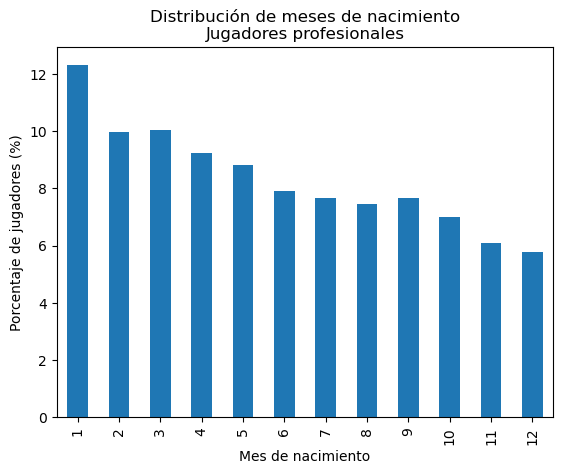

In [11]:
import matplotlib.pyplot as plt

plt.figure()
birth_month_pct.plot(kind='bar')
plt.xlabel("Mes de nacimiento")
plt.ylabel("Porcentaje de jugadores (%)")
plt.title("Distribución de meses de nacimiento\nJugadores profesionales")
plt.show()


In [12]:
cols_needed = [
    'player_id',
    'player_name',
    'date_of_birth',
    'country_of_birth',
    'citizenship',
    'birth_month',
    'birth_quarter'
]

df_clean = df[cols_needed].copy()


In [15]:
output_path = "C:/Users/lmosquen/Desktop/Python/Jugadores enero/data/processed/player_profiles_clean.csv"

df_clean.to_csv(output_path, index=False)


In [16]:
pd.read_csv(output_path).head()


,player_id,player_name,date_of_birth,country_of_birth,citizenship,birth_month,birth_quarter
0,1,Silvio Adzic (1),1980-09-23,Germany,Germany,9,3
1,100011,Éverton Silva (100011),1988-08-04,Brazil,Brazil,8,3
2,10,Miroslav Klose (10),1978-06-09,Germany,Germany,6,2
3,10001,John Thompson (10001),1981-10-12,Ireland,Ireland,10,4
4,100001,Carlos Auzqui (100001),1991-03-16,Argentina,Argentina,3,1
